---
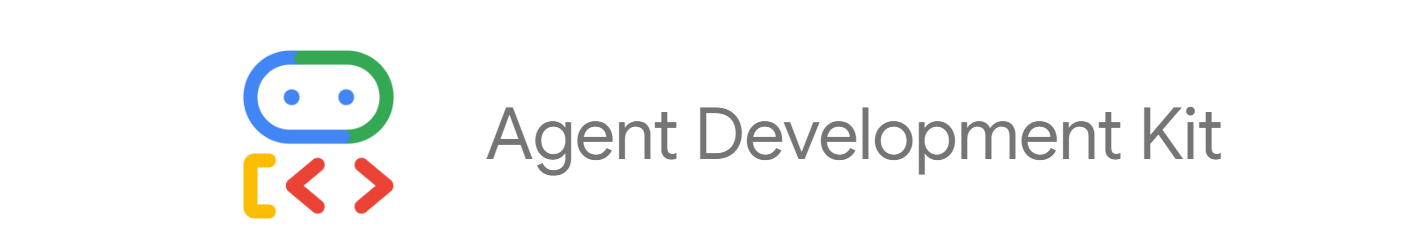

---

# Module 10: Callbacks: Observe, Customize, and Control Agent Behavior
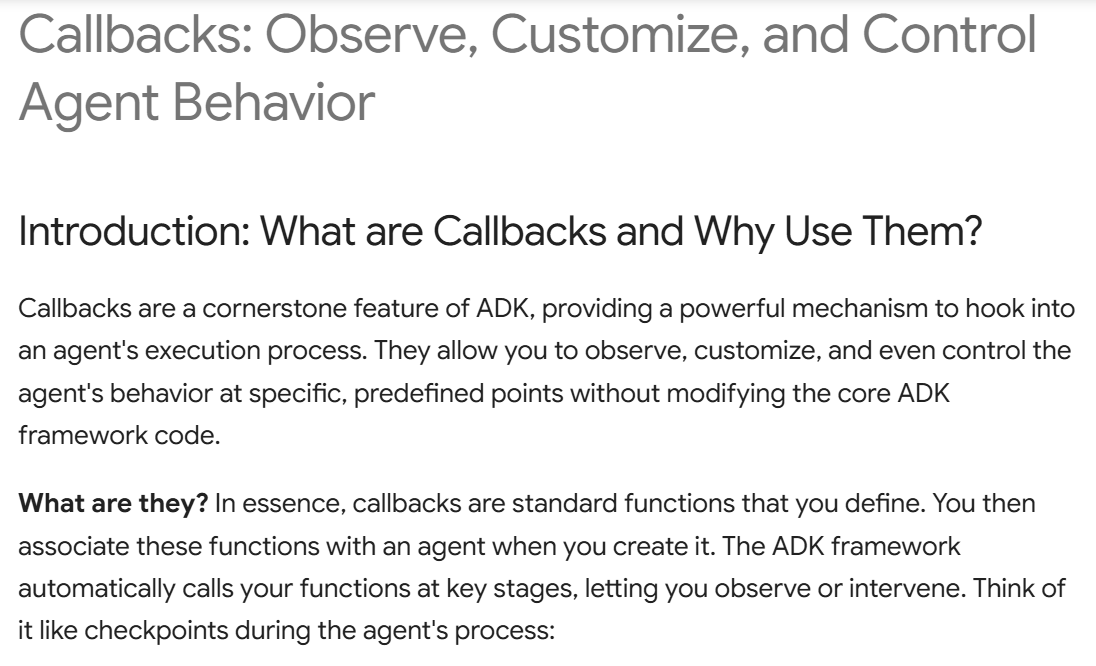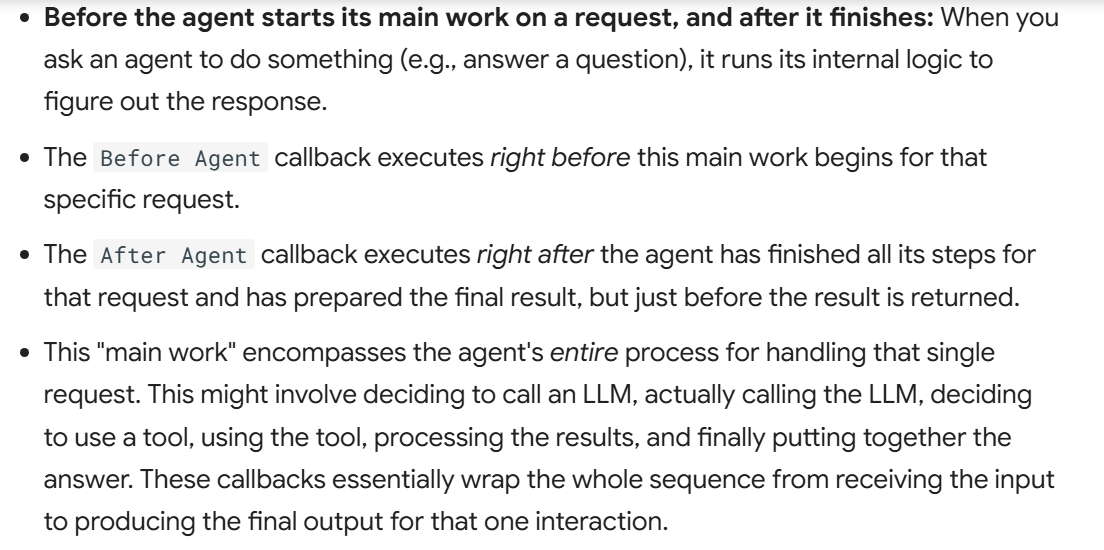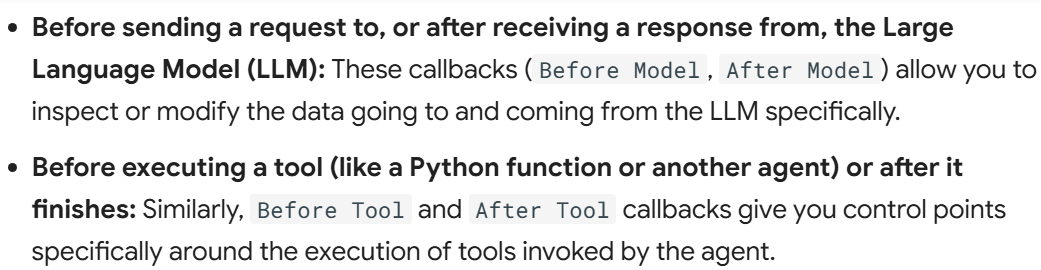 <br><br>

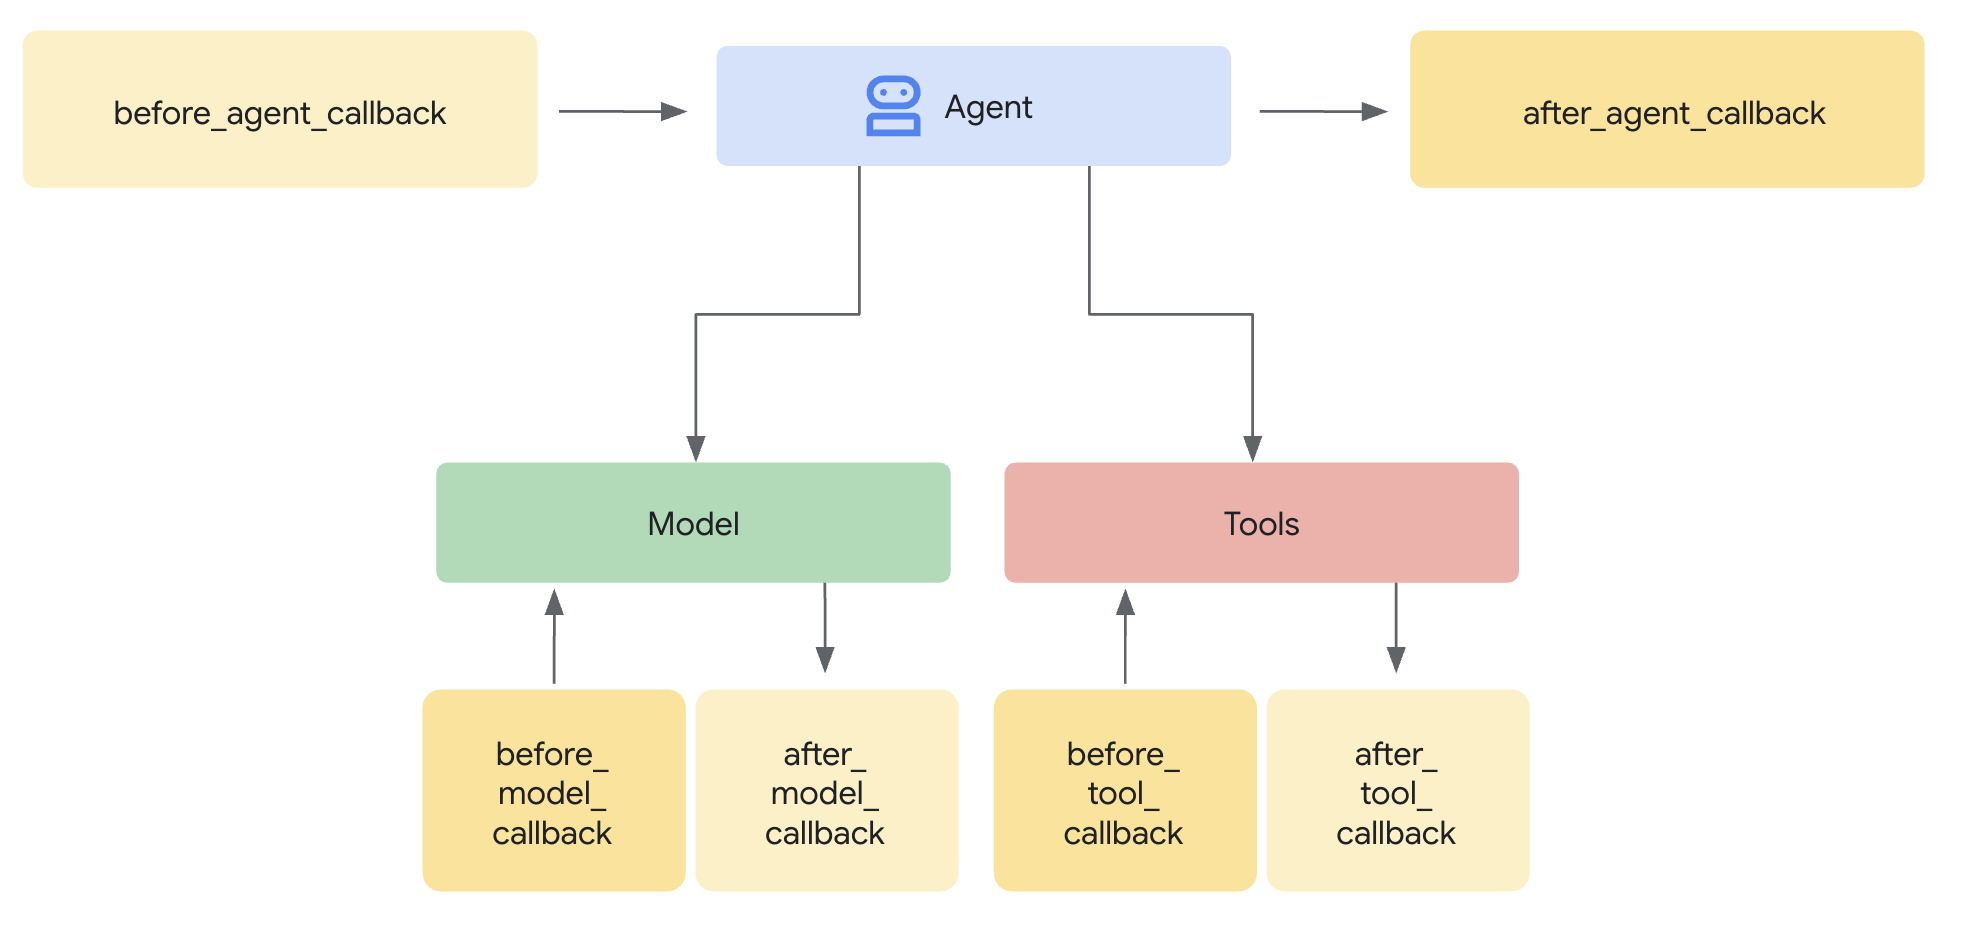 <br><br>

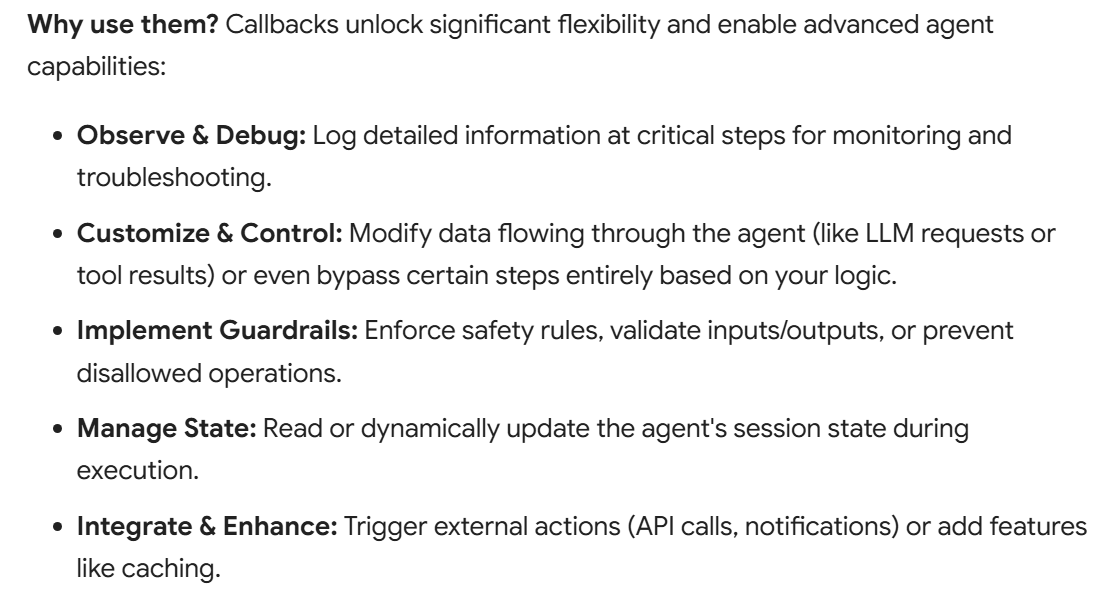 

> Tip <br> When implementing security guardrails and policies, use ADK Plugins for better modularity and flexibility than Callbacks. For more details, see [Callbacks and Plugins for Security Guardrails](https://google.github.io/adk-docs/safety/#callbacks-and-plugins-for-security-guardrails).

## `Where callbacks fire`
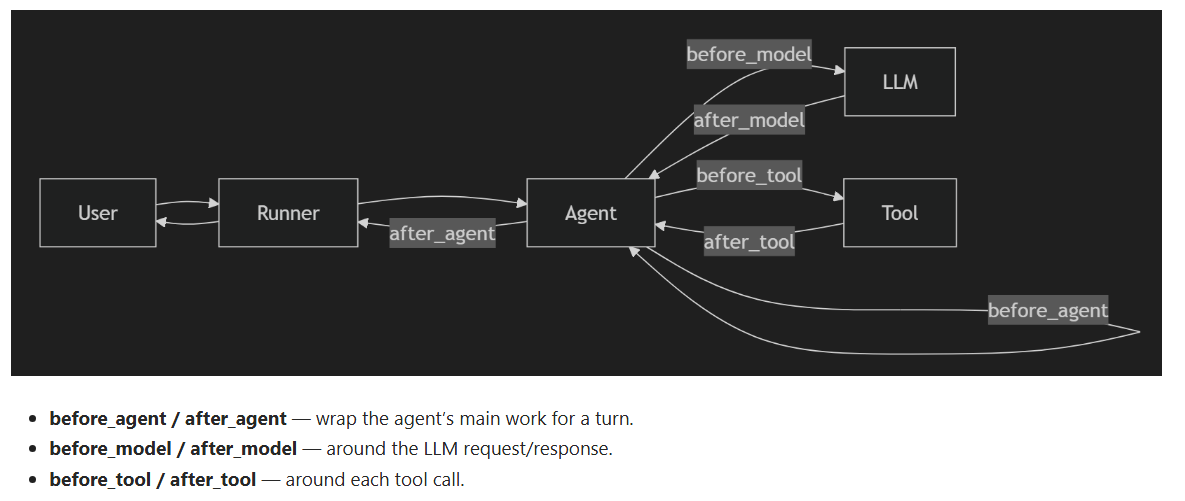

## `Code`
```Python
from google.adk.agents import LlmAgent
from google.adk.agents.callback_context import CallbackContext
from google.adk.models import LlmResponse, LlmRequest
from typing import Optional

# --- Define your callback function ---
def my_before_model_logic(
    callback_context: CallbackContext, llm_request: LlmRequest
) -> Optional[LlmResponse]:
    print(f"Callback running before model call for agent: {callback_context.agent_name}")
    # ... your custom logic here ...
    return None # Allow the model call to proceed

# --- Register it during Agent creation ---
my_agent = LlmAgent(
    name="MyCallbackAgent",
    model="gemini-2.0-flash", # Or your desired model
    instruction="Be helpful.",
    # Other agent parameters...
    before_model_callback=my_before_model_logic # Pass the function here
)
```

# The Callback Mechanism: Interception and Control
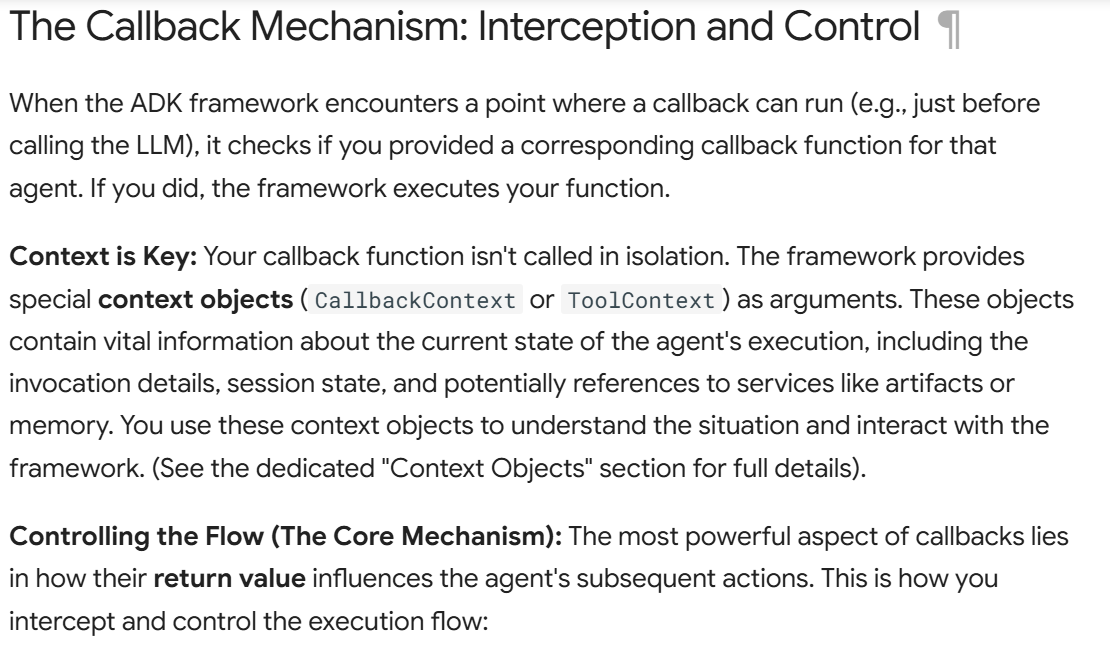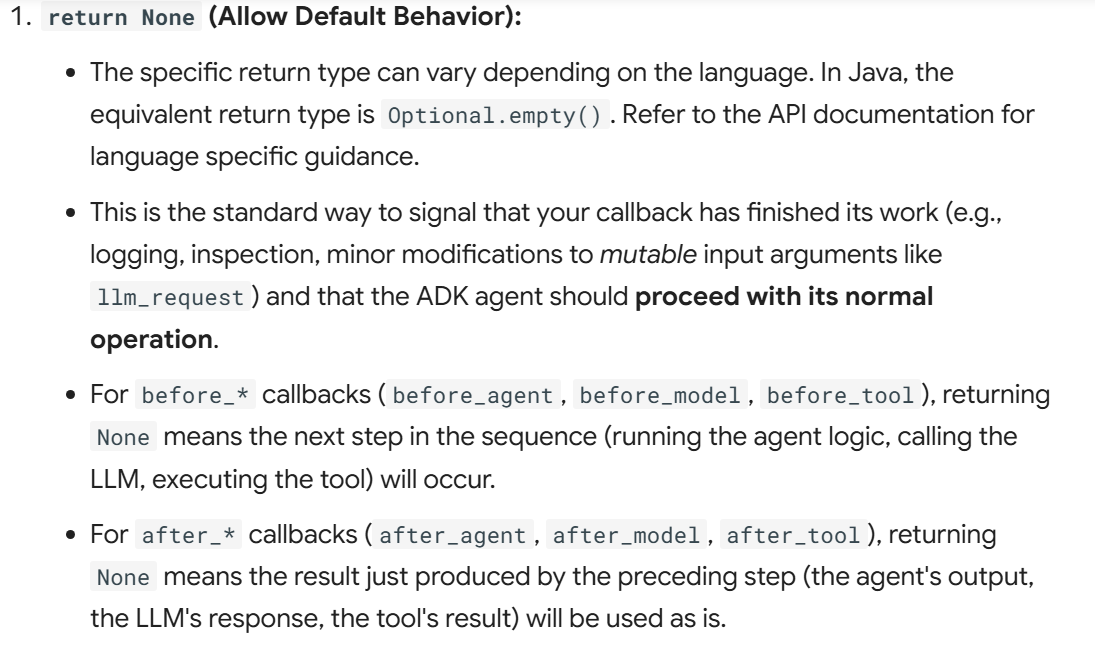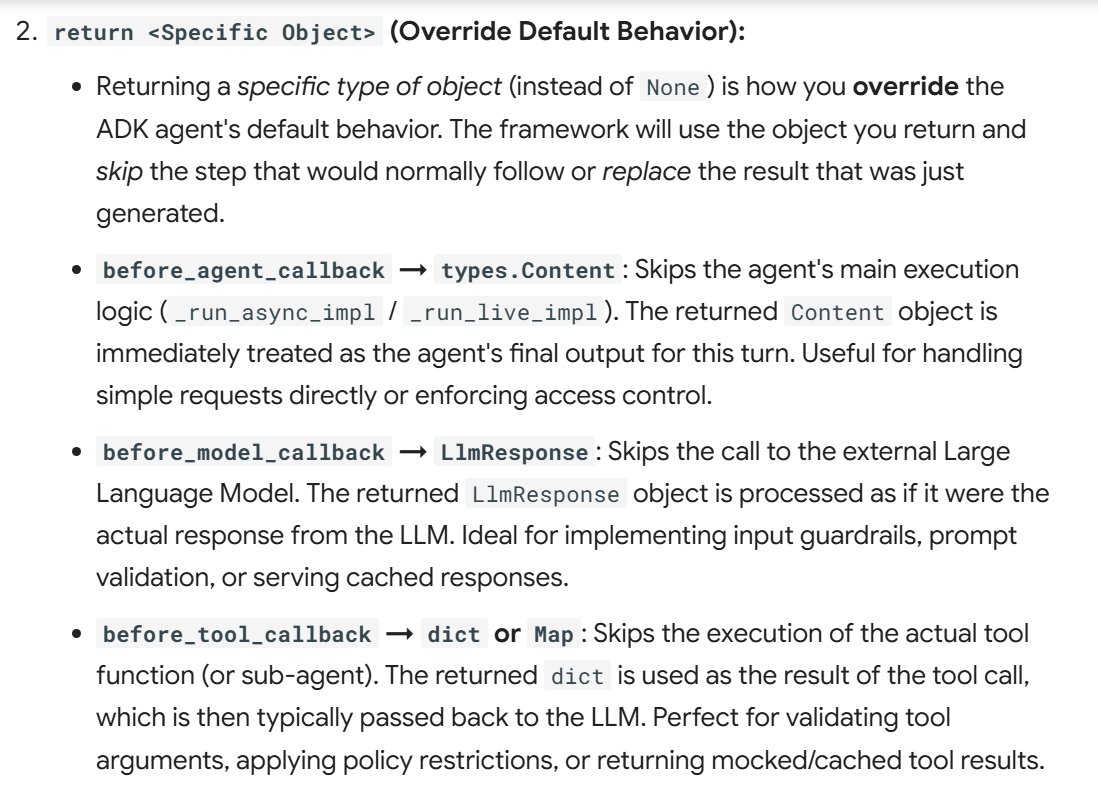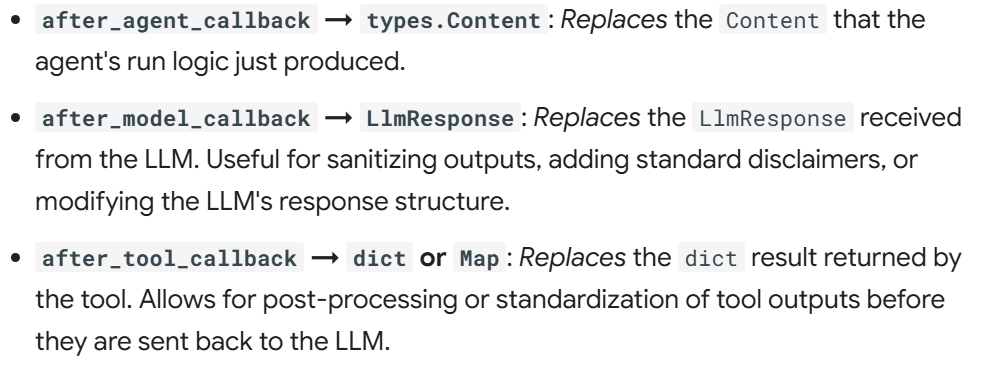

## `Conceptual Code Example (Guardrail):`
### This example demonstrates the common pattern for a guardrail using `before_model_callback`.
```Python
# Copyright 2025 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

from google.adk.agents import LlmAgent
from google.adk.agents.callback_context import CallbackContext
from google.adk.models import LlmResponse, LlmRequest
from google.adk.runners import Runner
from typing import Optional
from google.genai import types 
from google.adk.sessions import InMemorySessionService

GEMINI_2_FLASH="gemini-2.0-flash"

# --- Define the Callback Function ---
def simple_before_model_modifier(
    callback_context: CallbackContext, llm_request: LlmRequest
) -> Optional[LlmResponse]:
    """Inspects/modifies the LLM request or skips the call."""
    agent_name = callback_context.agent_name
    print(f"[Callback] Before model call for agent: {agent_name}")

    # Inspect the last user message in the request contents
    last_user_message = ""
    if llm_request.contents and llm_request.contents[-1].role == 'user':
         if llm_request.contents[-1].parts:
            last_user_message = llm_request.contents[-1].parts[0].text
    print(f"[Callback] Inspecting last user message: '{last_user_message}'")

    # --- Modification Example ---
    # Add a prefix to the system instruction
    original_instruction = llm_request.config.system_instruction or types.Content(role="system", parts=[])
    prefix = "[Modified by Callback] "
    # Ensure system_instruction is Content and parts list exists
    if not isinstance(original_instruction, types.Content):
         # Handle case where it might be a string (though config expects Content)
         original_instruction = types.Content(role="system", parts=[types.Part(text=str(original_instruction))])
    if not original_instruction.parts:
        original_instruction.parts.append(types.Part(text="")) # Add an empty part if none exist

    # Modify the text of the first part
    modified_text = prefix + (original_instruction.parts[0].text or "")
    original_instruction.parts[0].text = modified_text
    llm_request.config.system_instruction = original_instruction
    print(f"[Callback] Modified system instruction to: '{modified_text}'")

    # --- Skip Example ---
    # Check if the last user message contains "BLOCK"
    if "BLOCK" in last_user_message.upper():
        print("[Callback] 'BLOCK' keyword found. Skipping LLM call.")
        # Return an LlmResponse to skip the actual LLM call
        return LlmResponse(
            content=types.Content(
                role="model",
                parts=[types.Part(text="LLM call was blocked by before_model_callback.")],
            )
        )
    else:
        print("[Callback] Proceeding with LLM call.")
        # Return None to allow the (modified) request to go to the LLM
        return None


# Create LlmAgent and Assign Callback
my_llm_agent = LlmAgent(
        name="ModelCallbackAgent",
        model=GEMINI_2_FLASH,
        instruction="You are a helpful assistant.", # Base instruction
        description="An LLM agent demonstrating before_model_callback",
        before_model_callback=simple_before_model_modifier # Assign the function here
)

APP_NAME = "guardrail_app"
USER_ID = "user_1"
SESSION_ID = "session_001"

# Session and Runner
async def setup_session_and_runner():
    session_service = InMemorySessionService()
    session = await session_service.create_session(app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID)
    runner = Runner(agent=my_llm_agent, app_name=APP_NAME, session_service=session_service)
    return session, runner


# Agent Interaction
async def call_agent_async(query):
    content = types.Content(role='user', parts=[types.Part(text=query)])
    session, runner = await setup_session_and_runner()
    events = runner.run_async(user_id=USER_ID, session_id=SESSION_ID, new_message=content)

    async for event in events:
        if event.is_final_response():
            final_response = event.content.parts[0].text
            print("Agent Response: ", final_response)

# Note: In Colab, you can directly use 'await' at the top level.
# If running this code as a standalone Python script, you'll need to use asyncio.run() or manage the event loop.
await call_agent_async("write a joke on BLOCK")
```

> By understanding this mechanism of returning `None` versus returning specific objects, you can precisely control the agent's execution path, making callbacks an essential tool for building sophisticated and reliable agents with `ADK`.

---